# Chicago Food Inspection Outcomes in Three ZIP Codes, 2010–2018

**Jerry R. Napier**

This notebook revises a 2018 IM 720 course project for reproducibility. It retains the original ZIP-code scope and study period while replacing the unavailable local CSV with a documented snapshot from the City of Chicago Data Portal.

## Summary

Across 13,333 inspection records, the two headline measures identify different ZIP codes: 60622 has the highest recorded failure share (21.54%), while 60607 has the highest Risk 1 share (82.70% among records with a recognized risk classification). The divergence is decision-relevant because inspection outcome and facility-risk classification answer different questions.

These are descriptive inspection-level results. They can focus follow-up analysis, but repeated inspections, risk-dependent inspection frequency, and differences in inspection type prevent ZIP-code or establishment rankings and causal conclusions.

## Context & Methods

### Research questions

1. How are inspection outcomes distributed within each selected ZIP code?
2. What share of inspections in each ZIP code carries each recognized facility-risk classification?
3. How did the recorded failure share vary by year within the study period?

### Key assumptions

- One row represents one inspection, not one establishment.
- Outcome percentages use every inspection record in a ZIP code as the denominator.
- Risk percentages use records assigned to Risk 1, Risk 2, or Risk 3. Missing and nonstandard risk values are reported but excluded from that denominator.
- Annual failure share equals Fail records divided by all inspection records in the same ZIP code and year.
- The analysis is descriptive. It does not estimate causal effects or current restaurant safety.

The study ends before the City changed food-inspection procedures on July 1, 2018.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 20)
pd.set_option("display.max_rows", 20)

ZIP_CODES = ("60607", "60610", "60622")
EXPECTED_ROWS = 13_333
START_DATE = pd.Timestamp("2010-01-05")
END_DATE = pd.Timestamp("2018-06-13")
RISK_ORDER = ("Risk 1 (High)", "Risk 2 (Medium)", "Risk 3 (Low)")
RESULT_ORDER = (
    "Pass",
    "Fail",
    "Pass w/ Conditions",
    "Out of Business",
    "No Entry",
    "Not Ready",
    "Business Not Located",
)

data_candidates = (
    Path("../data/food_inspections_2010_2018.csv.gz"),
    Path("data/food_inspections_2010_2018.csv.gz"),
)
DATA_PATH = next((path for path in data_candidates if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Run this notebook from the repository root or notebooks directory.")

## Data

The source is the City of Chicago Food Inspections dataset, identifier 4ijn-s7e5. The repository snapshot contains only the seven fields used here. It was retrieved on July 19, 2026, with the fixed query documented in data/README.md.

The original 2018 notebook reported 12,971 records. The current historical snapshot contains 13,333. Since the original CSV is unavailable, the difference is treated as an unresolved source-revision effect rather than silently reconciled.

In [2]:
inspections = pd.read_csv(
    DATA_PATH,
    compression="gzip",
    dtype={"inspection_id": "string", "zip": "string"},
    parse_dates=["inspection_date"],
)
inspections = inspections.sort_values(["inspection_date", "inspection_id"]).reset_index(drop=True)

expected_columns = {
    "inspection_id",
    "facility_type",
    "risk",
    "zip",
    "inspection_date",
    "inspection_type",
    "results",
}

assert set(inspections.columns) == expected_columns
assert len(inspections) == EXPECTED_ROWS
assert inspections["inspection_id"].notna().all()
assert not inspections["inspection_id"].duplicated().any()
assert tuple(sorted(inspections["zip"].dropna().unique())) == ZIP_CODES
assert inspections["inspection_date"].min() == START_DATE
assert inspections["inspection_date"].max() == END_DATE
assert inspections["inspection_date"].notna().all()
assert inspections["results"].notna().all()

quality_summary = pd.Series(
    {
        "Inspection records": len(inspections),
        "Unique inspection IDs": inspections["inspection_id"].nunique(),
        "Duplicate inspection IDs": int(inspections["inspection_id"].duplicated().sum()),
        "Missing results": int(inspections["results"].isna().sum()),
        "Missing or nonstandard risk values": int(
            (~inspections["risk"].isin(RISK_ORDER)).sum()
        ),
        "First inspection date": inspections["inspection_date"].min().date().isoformat(),
        "Last inspection date": inspections["inspection_date"].max().date().isoformat(),
    },
    name="Value",
)
quality_summary.to_frame()

,Value
Inspection records,13333
Unique inspection IDs,13333
Duplicate inspection IDs,0
Missing results,0
Missing or nonstandard risk values,10
First inspection date,2010-01-05
Last inspection date,2018-06-13


The snapshot passes the required schema, identifier, date, and ZIP-code checks. Missing facility descriptions are retained because facility type is not used as a denominator or filter.

## Results

In [3]:
outcome_counts = (
    pd.crosstab(inspections["zip"], inspections["results"])
    .reindex(index=ZIP_CODES, columns=RESULT_ORDER, fill_value=0)
)
outcome_shares = outcome_counts.div(outcome_counts.sum(axis=1), axis=0) * 100

outcome_summary = pd.DataFrame(
    {
        "Inspections": outcome_counts.sum(axis=1),
        "Pass (%)": outcome_shares["Pass"],
        "Fail (%)": outcome_shares["Fail"],
        "Pass w/ Conditions (%)": outcome_shares["Pass w/ Conditions"],
        "Other result (%)": 100
        - outcome_shares[
            ["Pass", "Fail", "Pass w/ Conditions"]
        ].sum(axis=1),
    }
)
outcome_summary.index.name = "ZIP code"

assert outcome_shares.sum(axis=1).round(10).eq(100).all()
outcome_summary.style.format(
    {
        "Inspections": "{:,.0f}",
        "Pass (%)": "{:.2f}",
        "Fail (%)": "{:.2f}",
        "Pass w/ Conditions (%)": "{:.2f}",
        "Other result (%)": "{:.2f}",
    }
)

,Inspections,Pass (%),Fail (%),Pass w/ Conditions (%),Other result (%)
ZIP code,,,,,
60607,"4,442",60.15,20.53,10.47,8.85
60610,"3,553",54.35,18.77,14.89,11.99
60622,"5,338",57.76,21.54,8.77,11.93


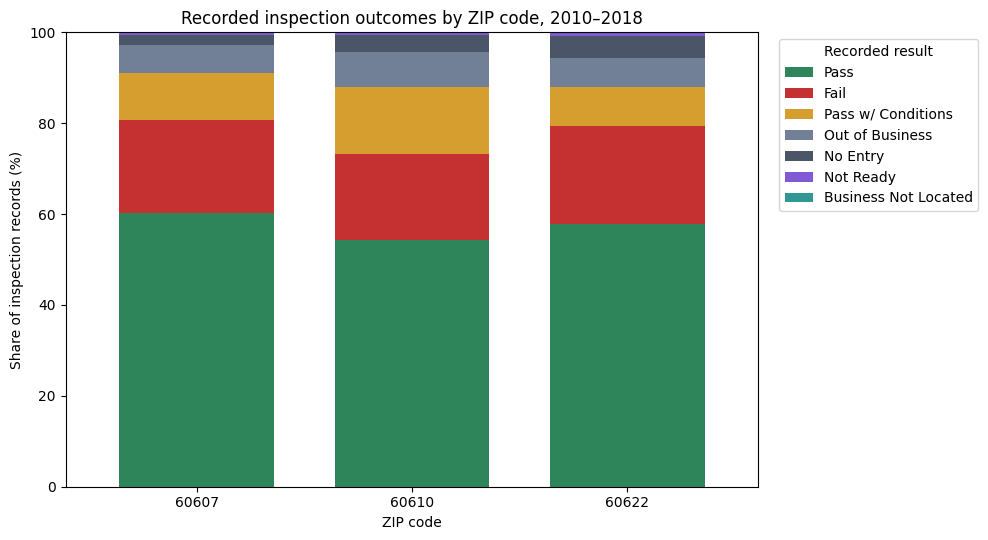

In [4]:
colors = {
    "Pass": "#2f855a",
    "Fail": "#c53030",
    "Pass w/ Conditions": "#d69e2e",
    "Out of Business": "#718096",
    "No Entry": "#4a5568",
    "Not Ready": "#805ad5",
    "Business Not Located": "#319795",
}

ax = outcome_shares.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5.5),
    color=[colors[column] for column in outcome_shares.columns],
    width=0.72,
)
ax.set_title("Recorded inspection outcomes by ZIP code, 2010–2018")
ax.set_xlabel("ZIP code")
ax.set_ylabel("Share of inspection records (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Recorded result", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [5]:
recognized_risk = inspections.loc[inspections["risk"].isin(RISK_ORDER)].copy()
risk_counts = (
    pd.crosstab(recognized_risk["zip"], recognized_risk["risk"])
    .reindex(index=ZIP_CODES, columns=RISK_ORDER, fill_value=0)
)
risk_shares = risk_counts.div(risk_counts.sum(axis=1), axis=0) * 100

risk_summary = risk_shares.rename(
    columns={
        "Risk 1 (High)": "Risk 1 (%)",
        "Risk 2 (Medium)": "Risk 2 (%)",
        "Risk 3 (Low)": "Risk 3 (%)",
    }
)
risk_summary.insert(0, "Classified inspections", risk_counts.sum(axis=1))
risk_summary["Excluded risk values"] = (
    inspections.groupby("zip").size() - risk_counts.sum(axis=1)
)
risk_summary.index.name = "ZIP code"

assert risk_shares.sum(axis=1).round(10).eq(100).all()
risk_summary.style.format(
    {
        "Classified inspections": "{:,.0f}",
        "Risk 1 (%)": "{:.2f}",
        "Risk 2 (%)": "{:.2f}",
        "Risk 3 (%)": "{:.2f}",
        "Excluded risk values": "{:,.0f}",
    }
)

risk,Classified inspections,Risk 1 (%),Risk 2 (%),Risk 3 (%),Excluded risk values
ZIP code,,,,,
60607,"4,439",82.70,12.93,4.37,3
60610,"3,553",81.48,10.61,7.91,0
60622,"5,331",76.85,16.66,6.49,7


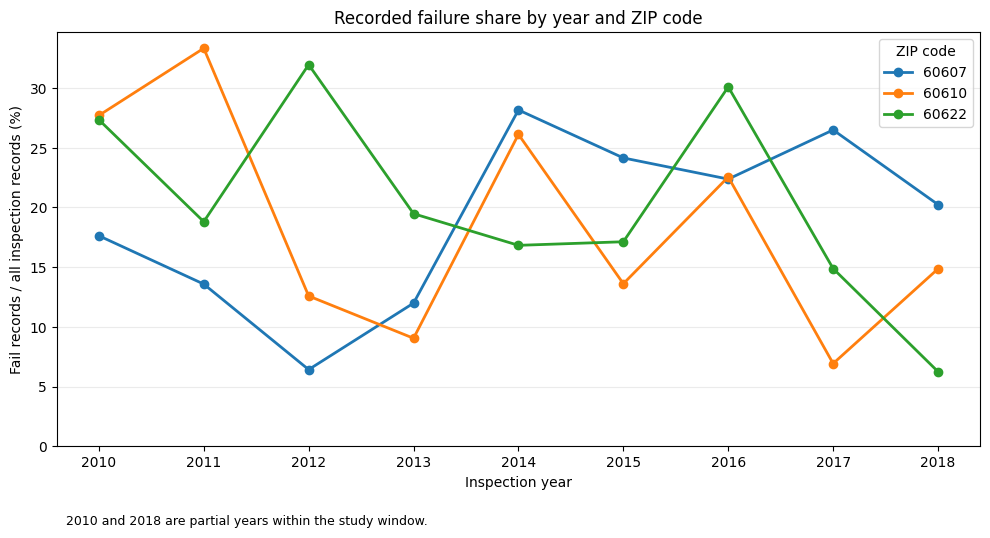

In [6]:
annual = inspections.assign(
    year=inspections["inspection_date"].dt.year,
    failed=inspections["results"].eq("Fail"),
).groupby(["year", "zip"], as_index=False).agg(
    inspections=("inspection_id", "size"),
    failures=("failed", "sum"),
)
annual["failure_share"] = annual["failures"] / annual["inspections"] * 100

annual_pivot = annual.pivot(index="year", columns="zip", values="failure_share")
ax = annual_pivot.plot(marker="o", figsize=(10, 5.5), linewidth=2)
ax.set_title("Recorded failure share by year and ZIP code")
ax.set_xlabel("Inspection year")
ax.set_ylabel("Fail records / all inspection records (%)")
ax.set_ylim(bottom=0)
ax.legend(title="ZIP code")
ax.grid(axis="y", alpha=0.25)
ax.text(
    0.01,
    -0.19,
    "2010 and 2018 are partial years within the study window.",
    transform=ax.transAxes,
    fontsize=9,
)
plt.tight_layout()
plt.show()

In [7]:
highest_failure_zip = outcome_summary["Fail (%)"].idxmax()
highest_failure_share = outcome_summary.loc[highest_failure_zip, "Fail (%)"]
highest_risk_zip = risk_summary["Risk 1 (%)"].idxmax()
highest_risk_share = risk_summary.loc[highest_risk_zip, "Risk 1 (%)"]

display(
    Markdown(
        f"""### Observed comparison

- **{highest_failure_zip}** has the highest recorded failure share: **{highest_failure_share:.2f}%** of inspection records.
- **{highest_risk_zip}** has the highest Risk 1 share: **{highest_risk_share:.2f}%** of records with a recognized risk classification.

The two measures identify different ZIP codes. Risk classification and inspection outcome describe different features of the inspection record and should not be treated as interchangeable measures."""
    )
)

### Observed comparison

- **60622** has the highest recorded failure share: **21.54%** of inspection records.
- **60607** has the highest Risk 1 share: **82.70%** of records with a recognized risk classification.

The two measures identify different ZIP codes. Risk classification and inspection outcome describe different features of the inspection record and should not be treated as interchangeable measures.

## Takeaways

- ZIP code 60622 has the highest recorded failure share in the bounded extract (21.54%).
- ZIP code 60607 has the highest proportion of recognized Risk 1 inspection records (82.70%).
- Because the leading ZIP differs by measure, no single indicator should stand in for inspection context.
- The annual series varies within every ZIP code; it does not support a single, time-invariant claim about an area.
- The next decision-relevant step would be an establishment-level analysis that separates repeat visits and inspection types before any operational prioritization.

## Limitations

1. Establishments can be inspected repeatedly, so records are not independent establishment observations.
2. Higher-risk facilities are inspected more often, which affects the composition of the data.
3. Complaint, licensing, canvass, and re-inspection records serve different purposes.
4. The three ZIP codes were selected for the original course project and do not represent Chicago as a whole.
5. The source agency may revise historical records. The 2018 extract is unavailable for a record-level reconciliation.
6. The period stops before the July 1, 2018 procedural change, so these results should not be joined directly to later records without accounting for that change.

### Source

City of Chicago, Chicago Department of Public Health. Food Inspections, dataset 4ijn-s7e5. Snapshot retrieved July 19, 2026.